# **Loading Dataset**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("US_Accidents_March23.csv")

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,7728394.0,2.212384,0.487531,1.000000,2.000000,2.000000,2.000000,4.000000
Start_Lat,7728394.0,36.201195,5.076079,24.554800,33.399631,35.823974,40.084959,49.002201
Start_Lng,7728394.0,-94.702545,17.391756,-124.623833,-117.219396,-87.766616,-80.353676,-67.113167
End_Lat,4325632.0,36.261829,5.272905,24.566013,33.462070,36.183495,40.178920,49.075000
End_Lng,4325632.0,-95.725570,18.107928,-124.545748,-117.754345,-88.027890,-80.247086,-67.109242
Distance(mi),7728394.0,0.561842,1.776811,0.000000,0.000000,0.030000,0.464000,441.750000
Temperature(F),7564541.0,61.663286,19.013653,-89.000000,49.000000,64.000000,76.000000,207.000000
Wind_Chill(F),5729375.0,58.251048,22.389832,-89.000000,43.000000,62.000000,75.000000,207.000000
Humidity(%),7554250.0,64.831041,22.820968,1.000000,48.000000,67.000000,84.000000,100.000000
Pressure(in),7587715.0,29.538986,1.006190,0.000000,29.370000,29.860000,30.030000,58.630000


# **Data Preperation**

In [6]:
accident = df.copy()

## **Missing Values**

In [7]:
# Check for missing values in the dataset
missing_values = accident.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(accident)) * 100

# Combine into a DataFrame for better visualization
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display missing values
print("Missing Values and Percentages:")
print(missing_data[missing_data['Missing Values'] > 0])


Missing Values and Percentages:
                       Missing Values  Percentage (%)
End_Lat                       3402762       44.029355
End_Lng                       3402762       44.029355
Precipitation(in)             2203586       28.512858
Wind_Chill(F)                 1999019       25.865904
Wind_Speed(mph)                571233        7.391355
Visibility(mi)                 177098        2.291524
Wind_Direction                 175206        2.267043
Humidity(%)                    174144        2.253301
Weather_Condition              173459        2.244438
Temperature(F)                 163853        2.120143
Pressure(in)                   140679        1.820288
Weather_Timestamp              120228        1.555666
Nautical_Twilight               23246        0.300787
Civil_Twilight                  23246        0.300787
Sunrise_Sunset                  23246        0.300787
Astronomical_Twilight           23246        0.300787
Airport_Code                    22635        0.292

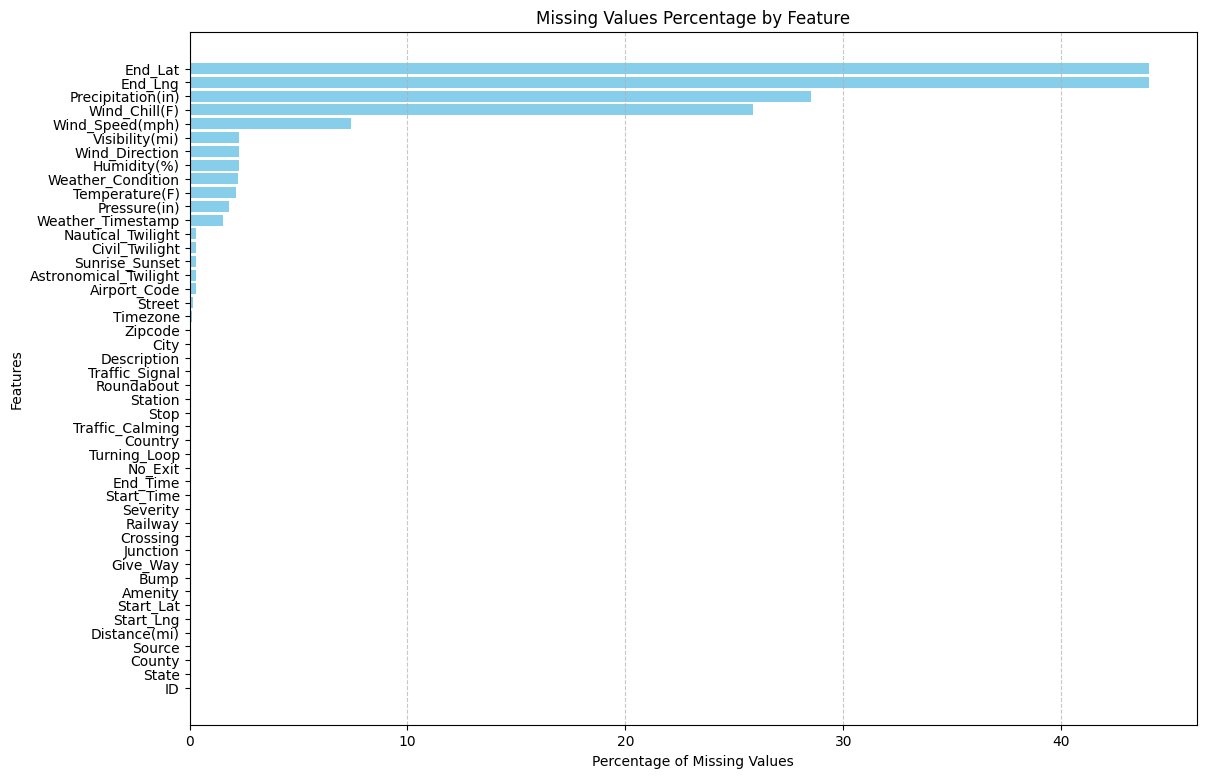

In [8]:
# Plot the missing values percentage
plt.figure(figsize=(13, 9))
plt.barh(missing_data.index, missing_data['Percentage (%)'], color='skyblue')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Features')
plt.title('Missing Values Percentage by Feature')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest percentage at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

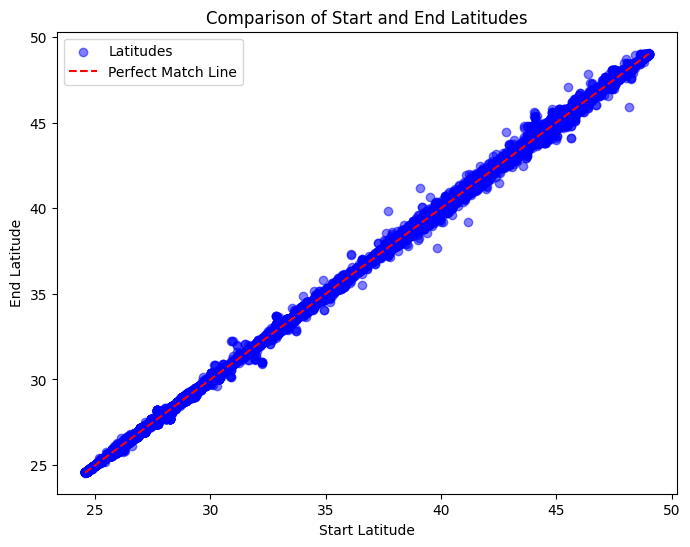

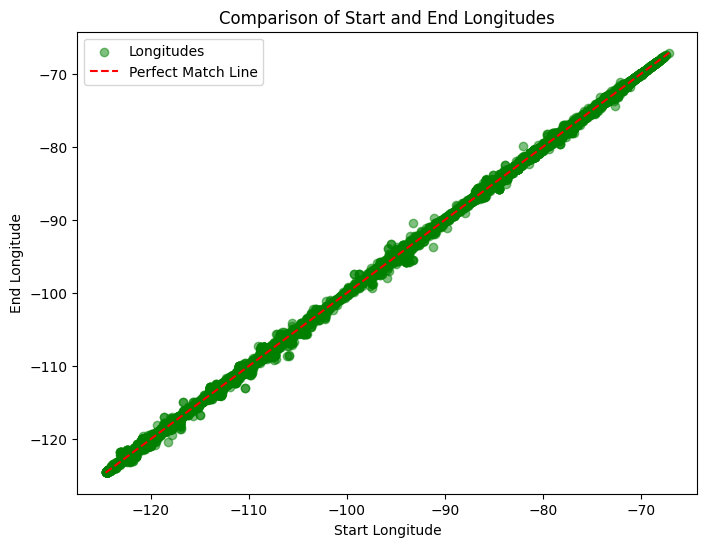

In [9]:
import matplotlib.pyplot as plt

# Scatter plot for Latitude comparison
plt.figure(figsize=(8, 6))
plt.scatter(df['Start_Lat'], df['End_Lat'], alpha=0.5, label='Latitudes', color='blue')
plt.plot([df['Start_Lat'].min(), df['Start_Lat'].max()],
         [df['Start_Lat'].min(), df['Start_Lat'].max()], 
         color='red', linestyle='--', label='Perfect Match Line')
plt.xlabel('Start Latitude')
plt.ylabel('End Latitude')
plt.title('Comparison of Start and End Latitudes')
plt.legend()
plt.show()

# Scatter plot for Longitude comparison
plt.figure(figsize=(8, 6))
plt.scatter(df['Start_Lng'], df['End_Lng'], alpha=0.5, label='Longitudes', color='green')
plt.plot([df['Start_Lng'].min(), df['Start_Lng'].max()],
         [df['Start_Lng'].min(), df['Start_Lng'].max()], 
         color='red', linestyle='--', label='Perfect Match Line')
plt.xlabel('Start Longitude')
plt.ylabel('End Longitude')
plt.title('Comparison of Start and End Longitudes')
plt.legend()
plt.show()


#The points are close to the diagonal red line (Perfect Match Line), it indicates high similarity between Start and End coordinates.

In [10]:
columns_to_drop = ['End_Lat', 'End_Lng']
accident = accident.drop(columns=columns_to_drop)

In [11]:
numerical_features=accident.select_dtypes(include=['float64','int64']).columns
categorical_features=accident.select_dtypes(include=['object']).columns

In [12]:
print("Numerical Features ",numerical_features)
print("Categorical Features ",categorical_features)

Numerical Features  Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)', 'Precipitation(in)'],
      dtype='object')
Categorical Features  Index(['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street',
       'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Wind_Direction',
       'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')


In [13]:
accident[numerical_features].describe()

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [14]:
import warnings
warnings.filterwarnings('ignore')

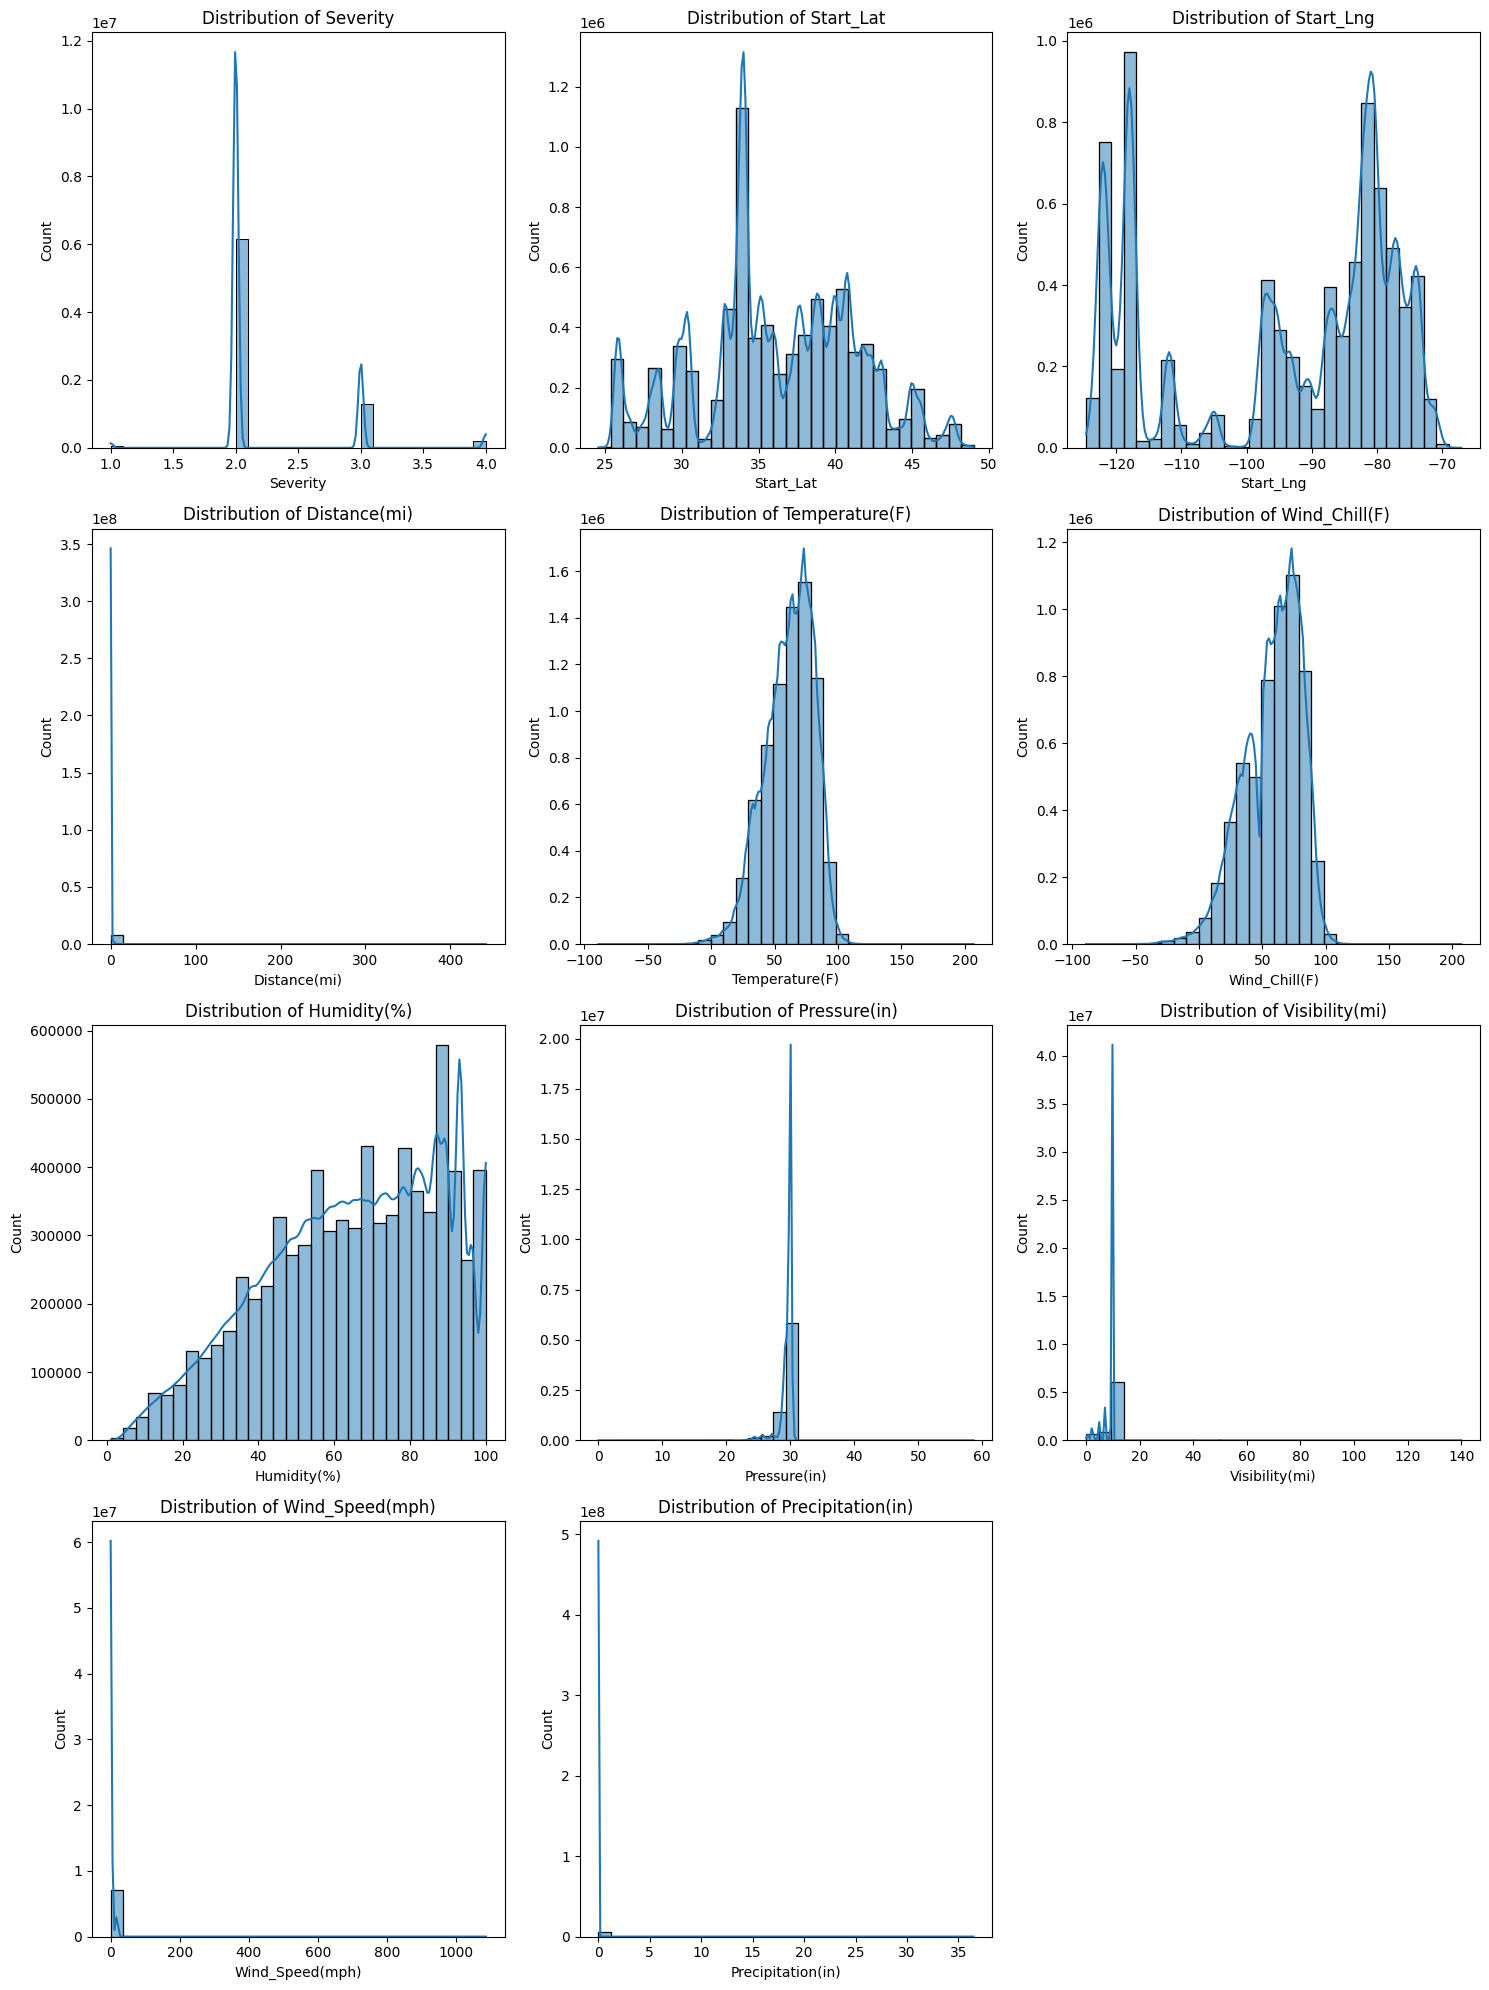

In [15]:
# Calculate the number of rows and columns needed for the subplots
num_features = len(numerical_features)
num_cols = 3  
num_rows = np.ceil(num_features / num_cols).astype(int)

# Set up the matplotlib figure
plt.figure(figsize=(num_cols * 5, num_rows * 5))

# Loop through each numerical feature and plot its distribution
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)  # Dynamically adjust grid size
    sns.histplot(accident[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()

In [16]:
# i will use the mean for filling  Temperature(F) and Wind_Chill(F) due to its symmetry
# and the median for other columns to mitigate the effects of outliers and skewed distributions.

columns_with_mean = ['Temperature(F)', 'Wind_Chill(F)']
accident[columns_with_mean] = accident[columns_with_mean].fillna(accident[columns_with_mean].mean())

fill_with_median = [col for col in numerical_features if col not in columns_with_mean]
accident[fill_with_median]=accident[fill_with_median].fillna(accident[fill_with_median].median())

In [17]:
# mode for the categorical cols
missing_categorical_cols = [col for col in categorical_features if accident[col].isnull().any()]

for col in missing_categorical_cols:
    accident[col] = accident[col].fillna(accident[col].mode()[0])

In [18]:
accident.isnull().sum()

ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Wind_Chill(F)            0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
T

## **Feature Selection**

In [19]:
#Dropping columns that are not part of the analysis
# List of columns to drop
columns_to_drop = ['ID', 'Description', 'County', 'Zipcode', 'Timezone', 'Airport_Code',
                   'Wind_Direction', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
# Drop the columns
accident = accident.drop(columns=columns_to_drop)

In [20]:
# check for unique values of each col
categorical_features=accident.select_dtypes(include=['object']).columns

for cat in categorical_features:
    print(cat, accident[cat].nunique())

Source 3
Start_Time 6131796
End_Time 6705355
Street 336306
City 13678
State 49
Country 1
Weather_Timestamp 941331
Weather_Condition 144
Sunrise_Sunset 2


In [21]:
#drop country col because it has only one value
accident = accident.drop(columns=['Country'])

**I will encode the categorical features later before the modeling because i need the categories to better understand the EDA analysis**

## **Class Distribution**

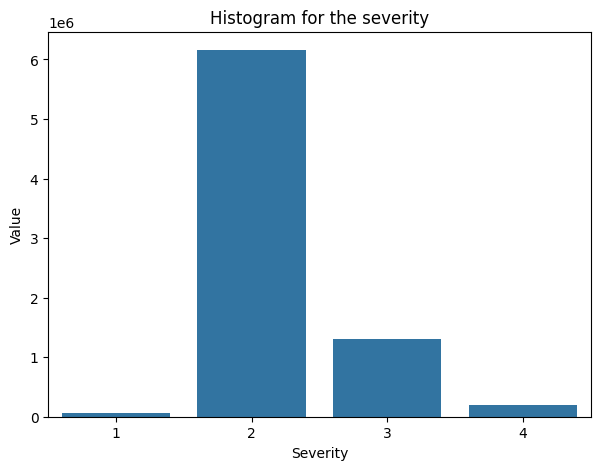

In [22]:
#check if the data is unbalenced
severity_counts = accident["Severity"].value_counts()

plt.figure(figsize=(7, 5))
plt.title("Histogram for the severity")
sns.barplot(x=severity_counts.index, y=severity_counts.values)
plt.xlabel("Severity")
plt.ylabel("Value")
plt.show()

**The severity attribute as we can see from the previous plot is highly unbalanced, the number of accident with the severity 1 is very small instead the number of accident with severity 2 is much higher. So, in order to balance the data we are going to undersample all the categories to the number of records of the minority category, in this case the severity 1.**

# **Exploratory Data Analysis**

## **Feature Scaling**

In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scalermax = MinMaxScaler()
scalerstd = StandardScaler()
fill_with_median = [col for col in fill_with_median if col != 'Severity']
accident[fill_with_median] = scalermax.fit_transform(accident[fill_with_median])
accident['Temperature(F)'] = scalerstd.fit_transform(accident[['Temperature(F)']])

## **EDA with visualization**

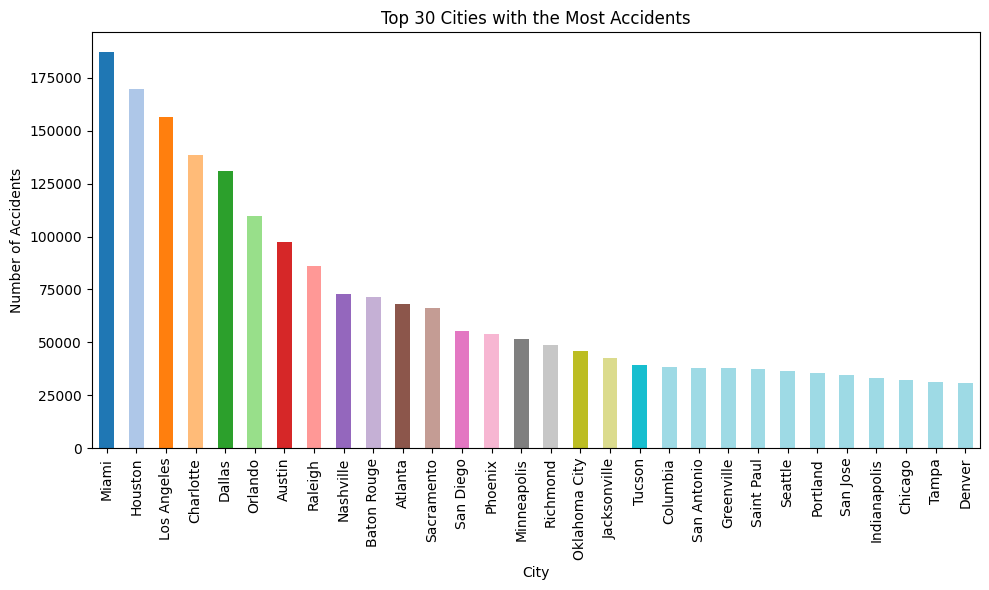

In [24]:
#Analysis by location:
# Get the top 30 cities with the most accidents
accidents_by_city = accident['City'].value_counts()

top_30_cities = accidents_by_city.head(30)

# Create the bar plot
plt.figure(figsize=(10, 6))
color_range = range(50)
top_30_cities.plot(kind='bar', color=plt.get_cmap('tab20')(range(len(color_range))))

plt.title('Top 30 Cities with the Most Accidents')
plt.xlabel('City')
plt.ylabel('Number of Accidents')

# Show the bar plot
plt.tight_layout()
plt.show()

 **Miami is the highest city with high number of accidents**

<Axes: xlabel='Start_Time', ylabel='Density'>

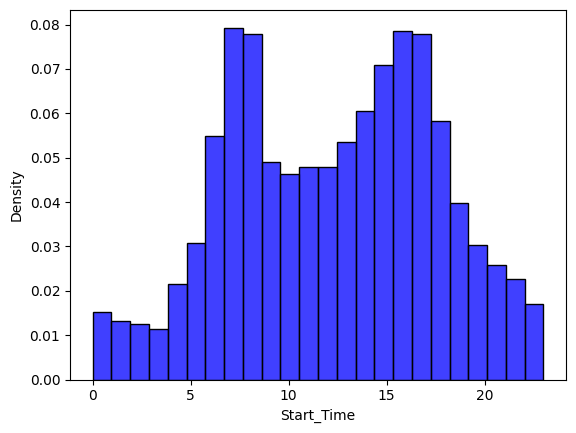

In [25]:
#Analaysis by Date
accident.Start_Time = pd.to_datetime(accident['Start_Time'] , format='mixed', errors='coerce' )
sns.histplot( accident.Start_Time.dt.hour , bins = 24 , kde = False, stat = 'density' ,color = 'blue')

**we see that most of the Accidents occured in between the 5am to 8pm**

<Axes: xlabel='Start_Time', ylabel='Density'>

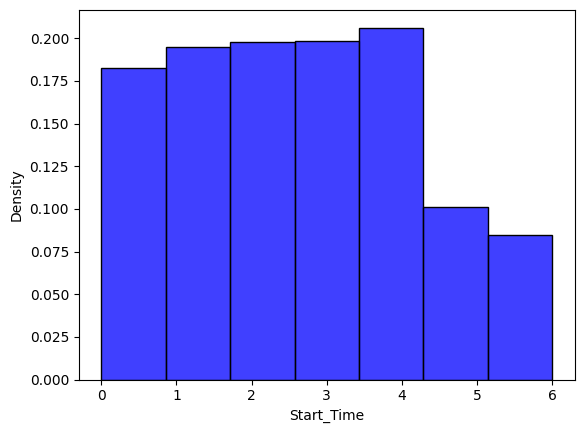

In [26]:
# US_Accidents.Start_Time.dt.dayofweek this give the day (actually the date from 30 days)

sns.histplot( accident.Start_Time.dt.dayofweek , bins = 7 , kde = False , stat = 'density' , color = 'blue')

# this give the day position in week...  0 : sunday , 1 : monday , 2 : tuesday , 3 :wednesday , 4 : thursday , 5 : friday , 6 : saturday

**The most accidents are during working days, while in the weekend we have less accidents.**

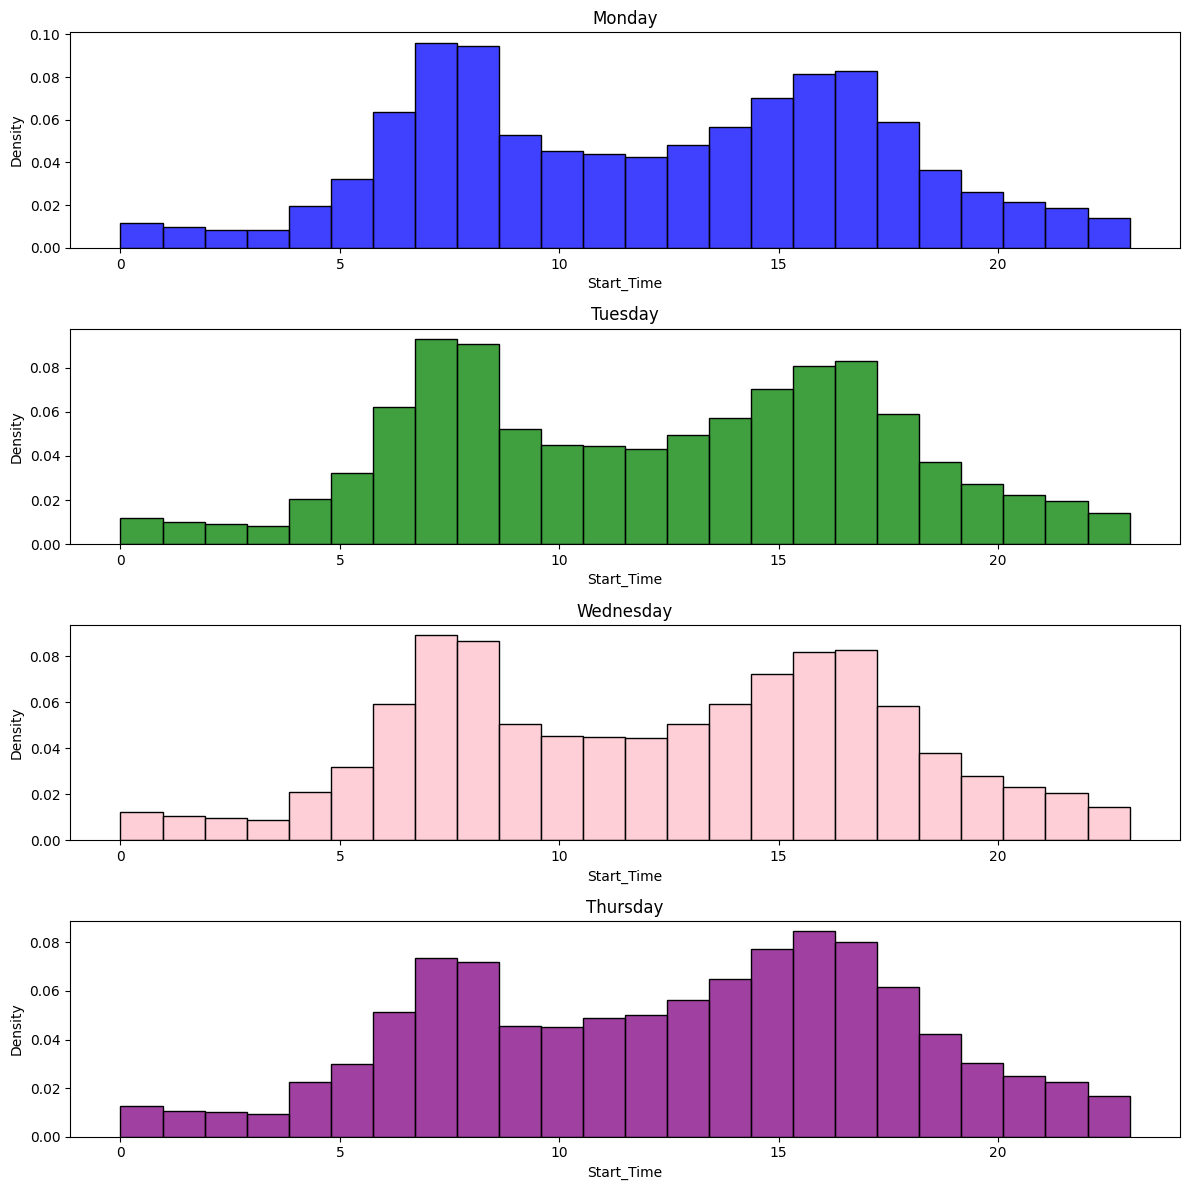

In [27]:
# checkout the distribution of accident on normal working day...

mon_day = accident.Start_Time[accident.Start_Time.dt.dayofweek == 1]
tues_day = accident.Start_Time[accident.Start_Time.dt.dayofweek == 2]
wednes_day = accident.Start_Time[accident.Start_Time.dt.dayofweek == 3]
thurs_day = accident.Start_Time[accident.Start_Time.dt.dayofweek == 4]

fig, axis = plt.subplots(4, 1, figsize=(12, 12))

sns.histplot(mon_day.dt.hour, bins=24, kde=False, stat='density', ax=axis[0], color='blue').set_title('Monday')
sns.histplot(tues_day.dt.hour, bins=24, kde=False, stat='density', ax=axis[1], color='green').set_title('Tuesday')
sns.histplot(wednes_day.dt.hour, bins=24, kde=False, stat='density', ax=axis[2], color='pink').set_title('Wednesday')
sns.histplot(thurs_day.dt.hour, bins=24, kde=False, stat='density', ax=axis[3], color='purple').set_title('Thursday')

fig.tight_layout()

**Most accidents are occured within the 6am to 9am and then 3 pm to 5 pm**

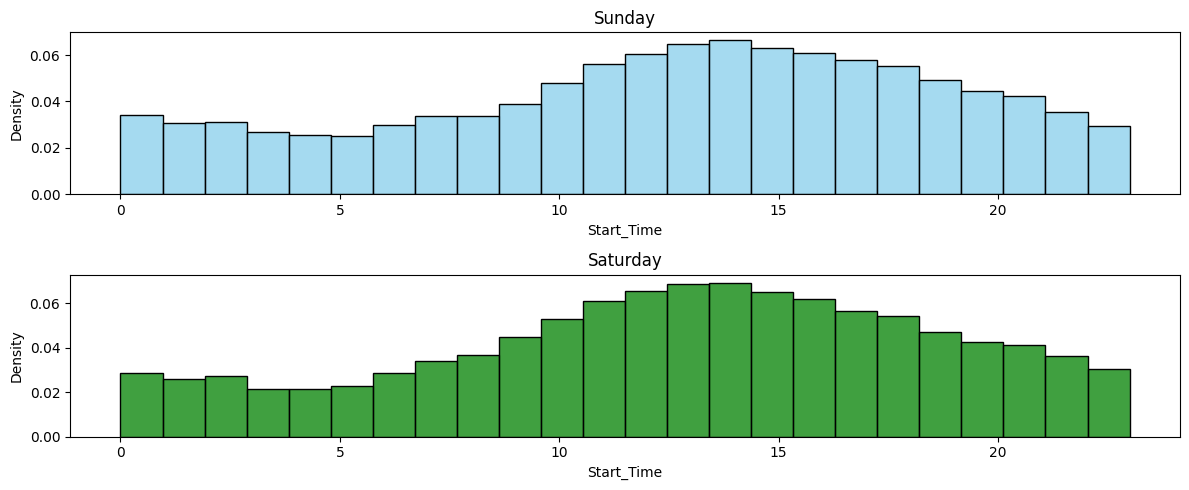

In [28]:
# now let's checkout the distribution of accident time on the weekends

sun_day = accident[accident.Start_Time.dt.dayofweek == 6]
sat_day = accident[accident.Start_Time.dt.dayofweek == 5]

fig, axis = plt.subplots(2, 1, figsize=(12, 5))

sns.histplot(sun_day.Start_Time.dt.hour, bins=24, kde=False, stat='density', ax=axis[0], color='skyblue')
axis[0].set_title('Sunday')

sns.histplot(sat_day.Start_Time.dt.hour, bins=24, kde=False, stat='density', ax=axis[1], color='green')
axis[1].set_title('Saturday')

fig.tight_layout()

plt.show()

**Most accidents are happened betwenn 10 am to 3pm**

## **Datetime Variables**

In [29]:
# handle datetime variables
accident['Start_Time'] = pd.to_datetime(accident['Start_Time'], errors='coerce', format='mixed')
accident['End_Time'] = pd.to_datetime(accident['End_Time'], errors='coerce', format='mixed')


#### **Feature Extraction**

In [30]:
# extract Relevant Features
accident['Start_Year'] = accident['Start_Time'].dt.year
accident['Start_Month'] = accident['Start_Time'].dt.month
accident['Start_Day'] = accident['Start_Time'].dt.day
accident['Start_Hour'] = accident['Start_Time'].dt.hour
accident['Start_Weekday'] = accident['Start_Time'].dt.weekday  # Monday=0, Sunday=6
accident['Is_Weekend'] = accident['Start_Weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [31]:
# drop the start time and end time variables
accident = accident.drop(columns=['Start_Time', 'End_Time'])

## **Feature Encoding**

In [32]:
# encoding 'Source'(3 cat) , 'Sunrise_Sunset'(2cat) with one hot encoding beacuse they don't have a lot of categories

accident = pd.get_dummies(accident, drop_first=True, columns=['Source', 'Sunrise_Sunset'])

In [33]:
# encoding street ,Weather_Timestamp, with target encoding because they have a lot of categories
# For 'Street'
street_mean = accident.groupby('Street')['Severity'].mean()
accident['Street'] = accident['Street'].map(street_mean)

# For 'Weather_Timestamp'
timestamp_mean = accident.groupby('Weather_Timestamp')['Severity'].mean()
accident['Weather_Timestamp'] = accident['Weather_Timestamp'].map(timestamp_mean)

# For 'city'
timestamp_mean = accident.groupby('City')['Severity'].mean()
accident['City'] = accident['City'].map(timestamp_mean)

# For 'weather_condition'
timestamp_mean = accident.groupby('Weather_Condition')['Severity'].mean()
accident['Weather_Condition'] = accident['Weather_Condition'].map(timestamp_mean)

In [34]:
#encode State with binary encoding
from category_encoders import BinaryEncoder
state_encoder = BinaryEncoder()
state_encoded = state_encoder.fit_transform(accident['State'])
accident = pd.concat([accident, state_encoded], axis=1)

# drop state
accident = accident.drop(columns=['State'])

In [36]:
accident.dtypes

Severity                  int64
Start_Lat               float64
Start_Lng               float64
Distance(mi)            float64
Street                  float64
City                    float64
Weather_Timestamp       float64
Temperature(F)          float64
Wind_Chill(F)           float64
Humidity(%)             float64
Pressure(in)            float64
Visibility(mi)          float64
Wind_Speed(mph)         float64
Precipitation(in)       float64
Weather_Condition       float64
Amenity                    bool
Bump                       bool
Crossing                   bool
Give_Way                   bool
Junction                   bool
No_Exit                    bool
Railway                    bool
Roundabout                 bool
Station                    bool
Stop                       bool
Traffic_Calming            bool
Traffic_Signal             bool
Turning_Loop               bool
Start_Year                int32
Start_Month               int32
Start_Day                 int32
Start_Ho

**All the feature are numerical**

### **Correlation Analysis**

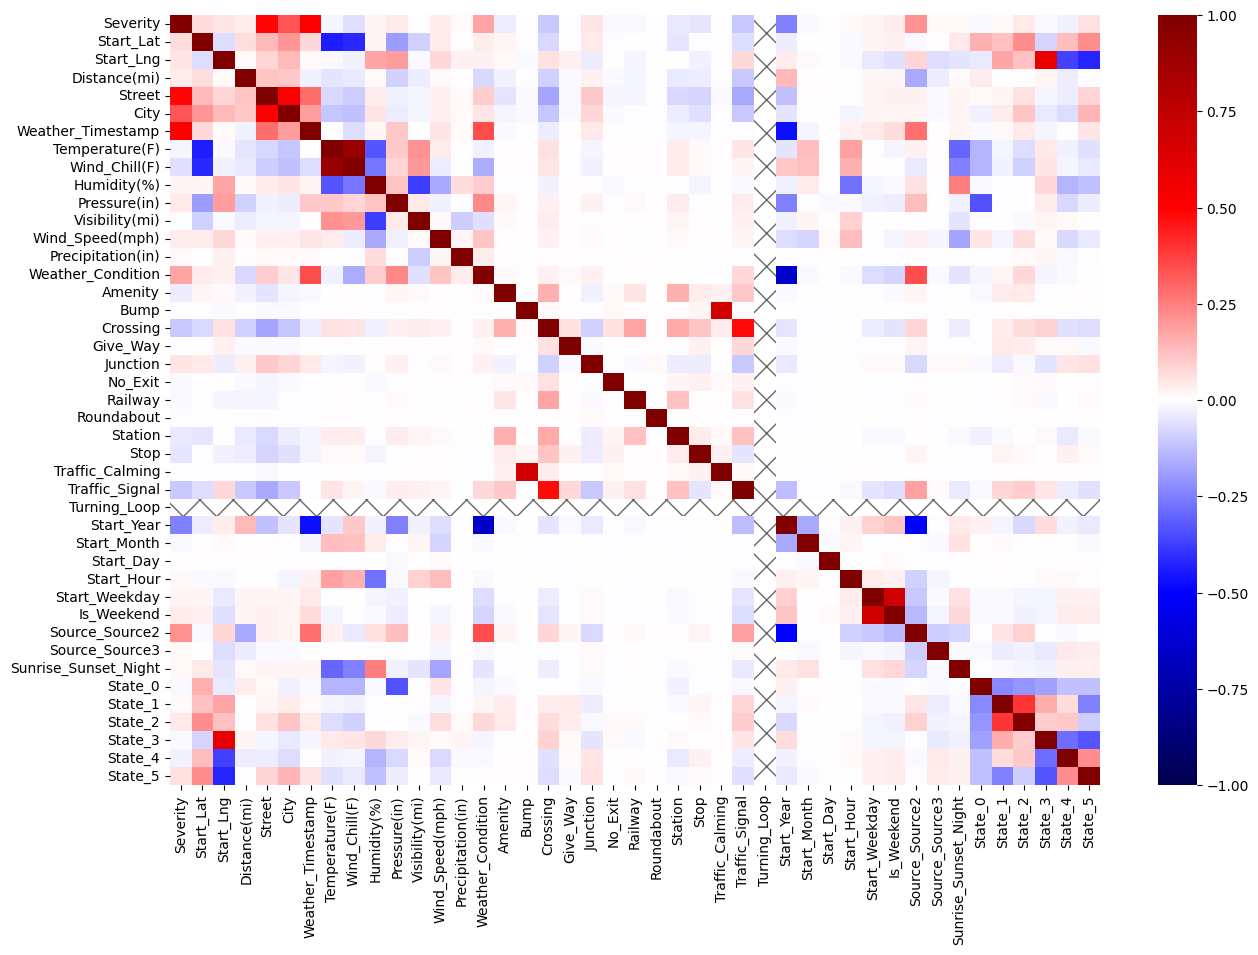

In [38]:
corr_matrix = accident.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap="seismic")
plt.gca().patch.set(hatch="X", edgecolor="#666")
plt.show()

**We can say it is hard tp understand here the really relationship between the feature, the best technique for this data is to make visualisations as we've done before to extarct real insights**

## **Handling Outliers**

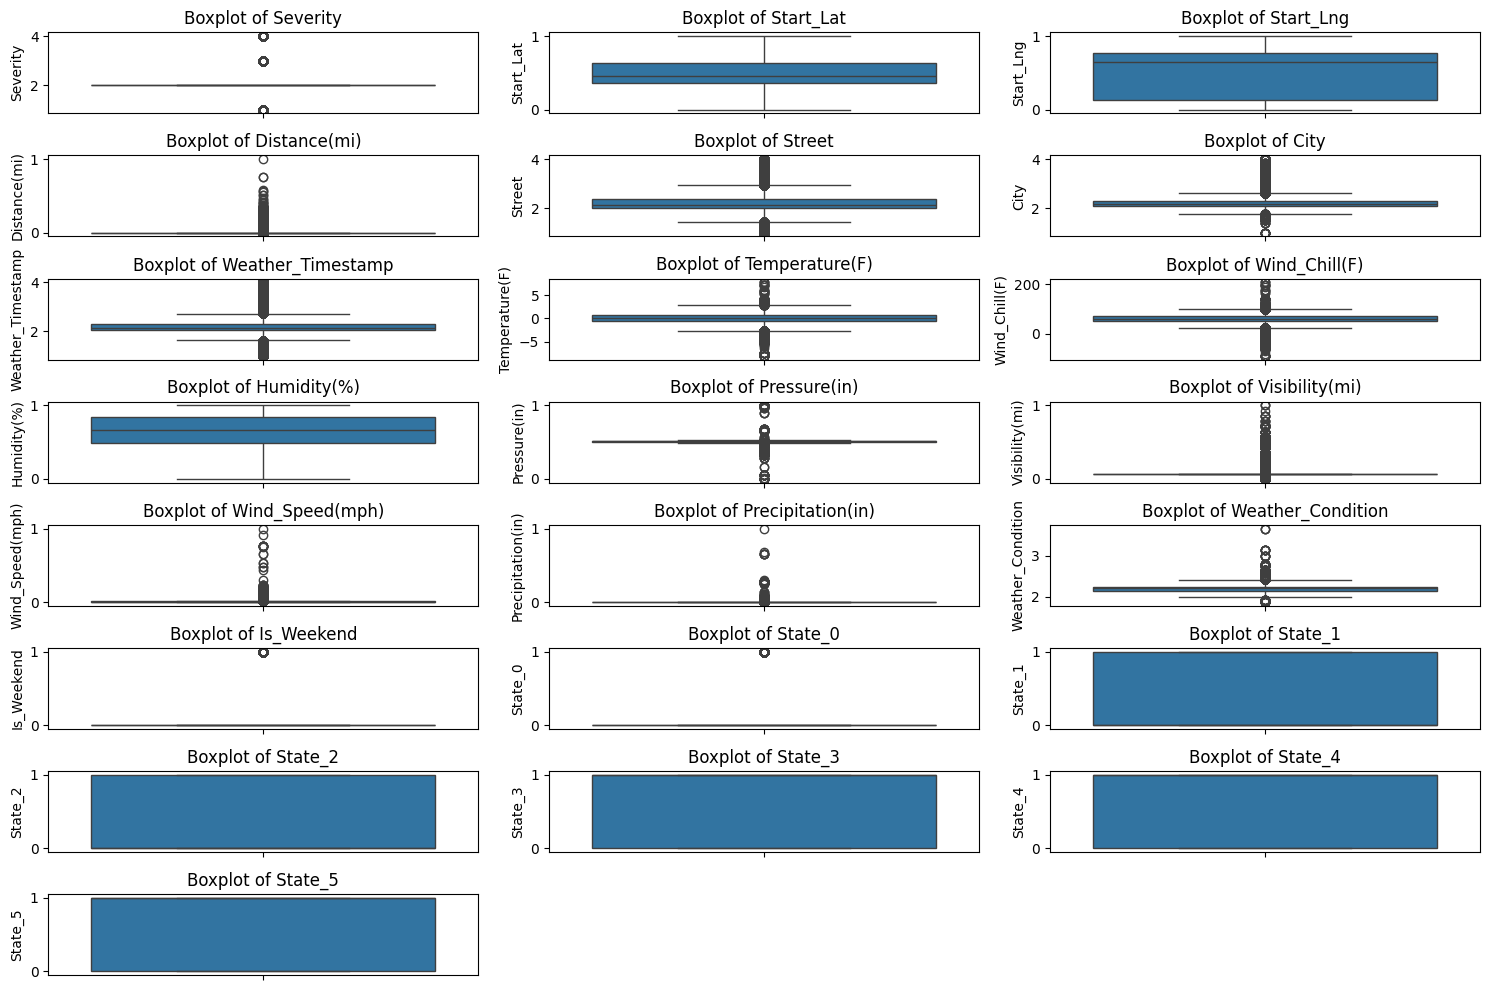

Column: Severity
Number of outliers: 1571413
--------------------
Column: Start_Lat
Number of outliers: 0
--------------------
Column: Start_Lng
Number of outliers: 0
--------------------
Column: Distance(mi)
Number of outliers: 963606
--------------------
Column: Street
Number of outliers: 61081
--------------------
Column: City
Number of outliers: 112293
--------------------
Column: Weather_Timestamp
Number of outliers: 343990
--------------------
Column: Temperature(F)
Number of outliers: 65279
--------------------
Column: Wind_Chill(F)
Number of outliers: 471296
--------------------
Column: Humidity(%)
Number of outliers: 0
--------------------
Column: Pressure(in)
Number of outliers: 449443
--------------------
Column: Visibility(mi)
Number of outliers: 1481065
--------------------
Column: Wind_Speed(mph)
Number of outliers: 291148
--------------------
Column: Precipitation(in)
Number of outliers: 533090
--------------------
Column: Weather_Condition
Number of outliers: 10137
----

In [40]:
# check the outliers of this dataset

numerical_cols = accident.select_dtypes(include=['float64', 'int64']).columns

# Box plots for outlier visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=accident[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Calculate IQR and identify outliers for each numerical column
outlier_info = {}  # Store outlier information for each column

for col in numerical_cols:
    Q1 = accident[col].quantile(0.25)
    Q3 = accident[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = accident[(accident[col] < lower_bound) | (accident[col] > upper_bound)]

    outlier_info[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'num_outliers': len(outliers),
    }

    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print("-" * 20)

In [43]:
# Handle outliers using IQR method

#remove severity from the numerical cols
numerical_cols = numerical_cols.drop('Severity')
for col in numerical_cols:
    Q1 = accident[col].quantile(0.25)
    Q3 = accident[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with the bounds
    accident[col] = np.where(accident[col] < lower_bound, lower_bound, accident[col])
    accident[col] = np.where(accident[col] > upper_bound, upper_bound, accident[col])

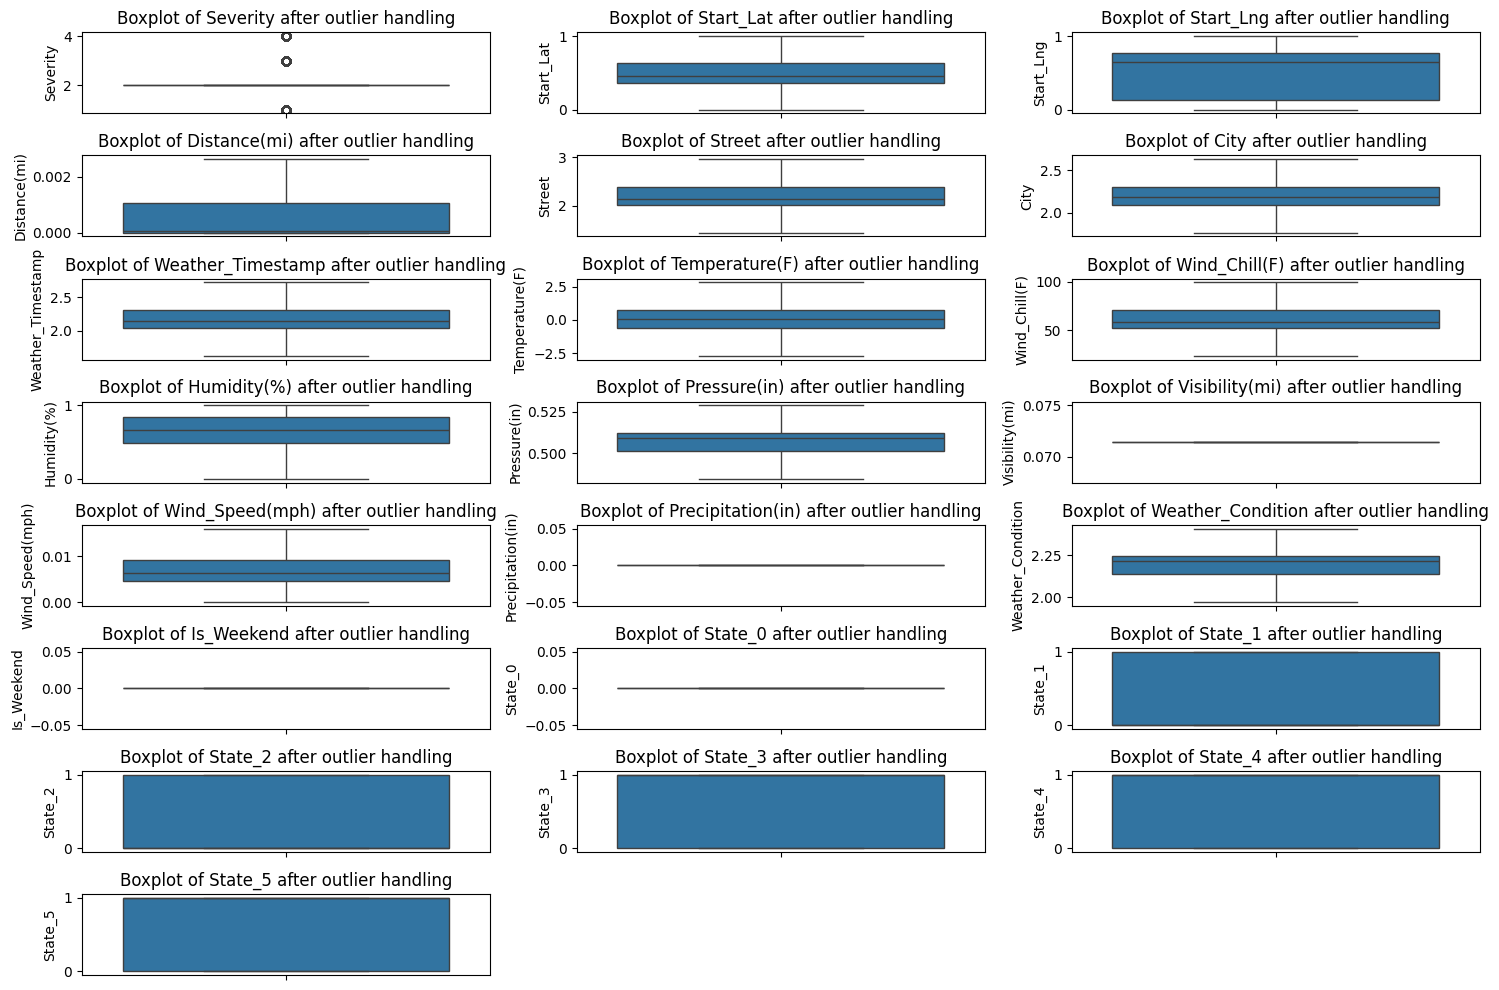

In [54]:
# Check for outliers after handling them
numerical_cols = accident.select_dtypes(include=['float64', 'int64']).columns

# Box plots for outlier visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=accident[col])
    plt.title(f'Boxplot of {col} after outlier handling')

plt.tight_layout()
plt.show()

### **Undersampling data**

In [44]:
# create a second version of data for undersampling
size = len(accident[accident["Severity"] == 1].index)
df_list = []  # Collect DataFrames in a list

for i in range(1, 5):
    S = accident[accident["Severity"] == i]
    df_list.append(S.sample(size, replace=True, random_state=42))

accidentV2 = pd.concat(df_list, ignore_index=True)

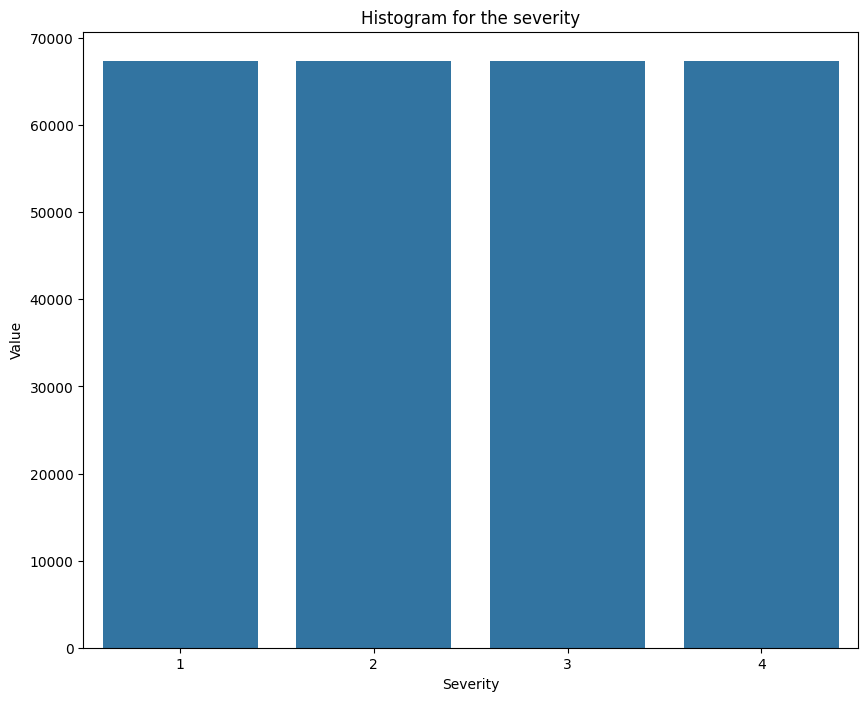

In [45]:
severity_counts = accidentV2["Severity"].value_counts()

plt.figure(figsize=(10, 8))
plt.title("Histogram for the severity")
sns.barplot(x=severity_counts.index, y=severity_counts.values)
plt.xlabel("Severity")
plt.ylabel("Value")
plt.show()

# **Data modeling**

In [46]:
# split data for modeling
from sklearn.model_selection import train_test_split
X = accident.drop(columns=['Severity'])
y = accident['Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [47]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and fit the logistic regression model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00     16834
           2       0.80      1.00      0.89   1538498
           3       0.00      0.00      0.00    325593
           4       0.00      0.00      0.00     51174

    accuracy                           0.80   1932099
   macro avg       0.20      0.25      0.22   1932099
weighted avg       0.63      0.80      0.71   1932099

Accuracy: 0.80
Confusion Matrix:
[[      0   16834       0       0]
 [      0 1538498       0       0]
 [      0  325593       0       0]
 [      0   51174       0       0]]


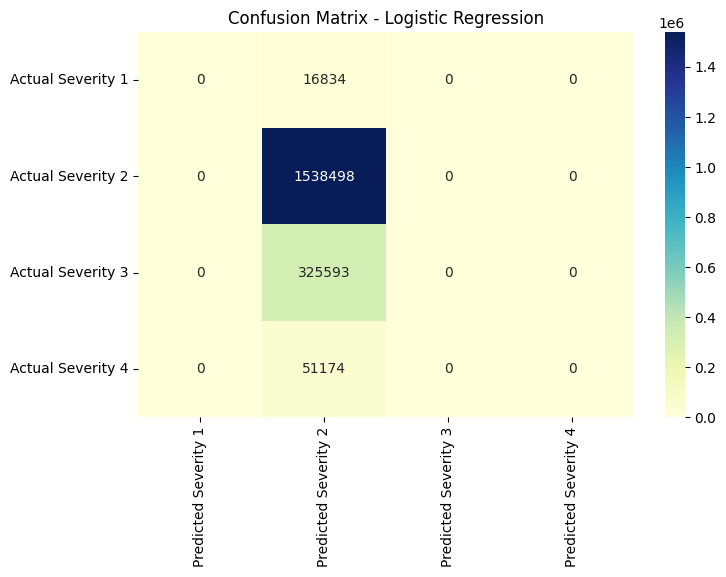

In [48]:
index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3", "Actual Severity 4"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3", "Predicted Severity 4"]
conf_matrix = pd.DataFrame(data=cm, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**The model is overwhelmingly predicting Severity 2 for most of the cases, regardless of the actual class.
Classes like Severity 1, Severity 3, and Severity 4 have very poor prediction rates, suggesting that the model is not learning to differentiate between these classes well.
There is some success in predicting Severity 2 correctly (seen by the large value in the corresponding diagonal cell: 1,481,524).
However, for other severity levels, off-diagonal values dominate, meaning the model is often misclassifying these cases as Severity 2.**

#### **Data with undersampling**

In [50]:
# split data for modeling
from sklearn.model_selection import train_test_split

X2 = accidentV2.drop(columns=['Severity'])
y2 = accidentV2['Severity']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr=LogisticRegression()
lr.fit(X_train2, y_train2)
y_pred2 = lr.predict(X_test2)
print(classification_report(y_test2, y_pred2))
cm2 = confusion_matrix(y_test2, y_pred2)

              precision    recall  f1-score   support

           1       0.46      0.72      0.56     16812
           2       0.35      0.27      0.31     16684
           3       0.52      0.42      0.47     16915
           4       0.50      0.42      0.45     16955

    accuracy                           0.46     67366
   macro avg       0.46      0.46      0.45     67366
weighted avg       0.46      0.46      0.45     67366



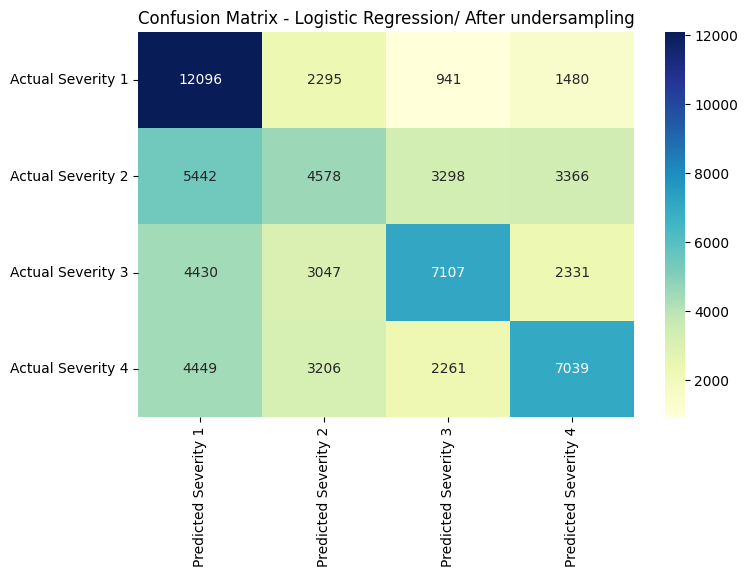

In [51]:
index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3", "Actual Severity 4"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3", "Predicted Severity 4"]
conf_matrix = pd.DataFrame(data=cm2, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Logistic Regression/ After undersampling")
plt.show()

**The results after undersampling reflect the challenges associated with balancing the dataset and its impact on the model's performance.But Undersampling often reduces the dataset size and may lead to some loss of information.**